In [3]:
import pandas as pd
df_sc = pd.read_csv('industry_scode_v3.csv') 
df_sc.head()

,Industry,Keyword,Code
0,바이오,유한양행,000100
1,바이오,삼성바이오,207940
2,바이오,한미약품,128940
3,바이오,대웅제약,069620
4,바이오,셀트리온,068270


In [5]:
import pandas as pd
import requests
from bs4 import BeautifulSoup
from io import StringIO

def get_stock_data_naver(code, name, industry):
    base_url = f"https://finance.naver.com/item/sise_day.nhn?code={code}"
    headers = {'User-Agent': 'Mozilla/5.0'}

    df_list = []
    for page in range(1, 136):
        url = f"{base_url}&page={page}"
        res = requests.get(url, headers=headers)
        soup = BeautifulSoup(res.text, 'lxml')
        table = soup.select_one('table.type2')
        df = pd.read_html(StringIO(str(table)), header=0)[0]
        df_list.append(df)
 
    df_all = pd.concat(df_list)
    df_all = df_all.dropna()
    
    df_all.columns = ['date', 'close', 'change', 'open', 'high', 'low', 'volume']
    df_all['date'] = pd.to_datetime(df_all['date'])
    df_all = df_all.sort_values('date')
    
    df_all = df_all[
    (df_all['date'] >= pd.to_datetime('2025-05-31')) &
    (df_all['date'] <= pd.to_datetime('2025-07-31'))]

    df_all = df_all.drop_duplicates(subset='date')
    
    df_all['industry'] = industry
    df_all['keyword'] = name
    df_all['ticker'] = code
        
    return df_all

In [7]:
# 한종목 테스트
result_df = get_stock_data_naver('003620 ', 'KG모빌리티', '자동차')
result_df

,date,close,change,open,high,low,volume,industry,keyword,ticker
9,2025-06-02,3380.0,하락 45,3475.0,3475.0,3360.0,217937.0,자동차,KG모빌리티,003620
5,2025-06-04,3420.0,상승 40,3380.0,3480.0,3335.0,235253.0,자동차,KG모빌리티,003620
4,2025-06-05,3435.0,상승 15,3400.0,3500.0,3400.0,268067.0,자동차,KG모빌리티,003620
3,2025-06-09,3445.0,상승 10,3450.0,3535.0,3445.0,421679.0,자동차,KG모빌리티,003620
2,2025-06-10,3450.0,상승 5,3440.0,3555.0,3430.0,599105.0,자동차,KG모빌리티,003620
1,2025-06-11,3450.0,보합0,3450.0,3485.0,3335.0,315431.0,자동차,KG모빌리티,003620
13,2025-06-12,3490.0,상승 40,3410.0,3500.0,3400.0,510177.0,자동차,KG모빌리티,003620
12,2025-06-13,3390.0,하락 100,3480.0,3500.0,3375.0,352419.0,자동차,KG모빌리티,003620
11,2025-06-16,3345.0,하락 45,3415.0,3415.0,3275.0,391547.0,자동차,KG모빌리티,003620
10,2025-06-17,3350.0,상승 5,3345.0,3435.0,3325.0,341094.0,자동차,KG모빌리티,003620


In [9]:
import yfinance as yf
#Yahoo Finance 데이터

def get_usd_krw_rate():
    fx_df = yf.download('USDKRW=X', start="2025-06-01", end="2025-07-31")
    fx_df = fx_df.reset_index()[['Date', 'Close']]
    fx_df.columns = ['date', 'exrate']
    fx_df['date'] = pd.to_datetime(fx_df['date'])
    fx_df['exrate'] = fx_df['exrate'].round(4)
    return fx_df

def get_us_stock_data(ticker, name, industry):
    df = yf.download(ticker, start="2025-06-01", end="2025-07-31")
    df = df.reset_index()
    df = df[['Date', 'Close','Open','High','Low','Volume']]
    df.columns = ['date', 'close','open','high','low','volume']

    df = pd.merge(df, df_rate, on='date', how='left')
        
    # 금액 컬럼 반올림, 당일 환율종가 반영
    if ticker not in ["^KS11", "^KQ11", "^IXIC", "^GSPC", "^DJI", "USDKRW=X", "USDJPY=X", "EURUSD=X", "USDCNY=X"]:
        for col in ['close', 'open', 'high', 'low']:
            df[col] = (df[col] * df['exrate']).round(0)
    
    # 전일비 계산 후 반올림
    diff = df['close'].diff().round(2)
    
    diff_text = []
    for val in diff:
        if pd.isna(val):
            diff_text.append('')  # 첫 줄은 공백 처리
        elif val > 0:
            diff_text.append(f'상승 {val:,.2f}')
        elif val < 0:
            diff_text.append(f'하락 {abs(val):,.2f}')
        else:
            diff_text.append(f'보합 0')
            
    df['change'] = diff_text
    df['keyword'] = name
    df['industry'] = industry
    df['ticker'] = ticker
    
    return df

In [11]:
from datetime import date

def fill_weekend_data(df):
   
    df['date'] = pd.to_datetime(df['date'])
    df = df.set_index('date')

    # 전체 날짜 범위 지정 (시작 ~ 끝까지 하루 단위)
    #full_index = pd.date_range(start='2025-01-02', end=date.today(), freq='D')
    full_index = pd.date_range(start='2025-06-01', end='2025-07-31', freq='D')
    
    df = df.reindex(full_index)

    # 결측값을 최근 데이터 월요일 값으로 채움 (주말뉴스는 월요일에 반영 될 가능성 높아요)
    df = df.fillna(method='bfill')
    
    df = df.reset_index().rename(columns={'index': 'date'})

    return df

In [13]:
# 산업군 대표 종목 리스트 불러오기
df_sc = pd.read_csv('industry_scode_v3.csv', dtype={'Code': str}) 
df_sc.head()

result_df = pd.DataFrame()

#일자별 환율 가져기기
df_rate = get_usd_krw_rate()

for _, row in df_sc.iterrows():
    code = row['Code']  # 종목코드, 코스피, 미국주식 티커
    name = row['Keyword']  # 종목 키워드
    industry = row['Industry']
    
   # if code.isdigit():
    df = get_stock_data_naver(code, name, industry)
   # else:
   #     df = get_us_stock_data(code, name, industry)       

    df = fill_weekend_data(df)
    
    result_df = pd.concat([result_df, df], ignore_index=True)

    print(f'산업군:{industry}, 키워드:{name}')

result_df.to_csv("stock_data_v3_2507.csv", index=False, encoding='utf-8-sig')
print("저장 완료: stock_data_v3_2507.csv")

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_12568\3387355133.py:16: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='bfill')


산업군:바이오, 키워드:유한양행


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_12568\3387355133.py:16: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='bfill')


산업군:바이오, 키워드:삼성바이오


...

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_12568\3387355133.py:16: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='bfill')


산업군:방송업, 키워드:제이콘텐트리


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_12568\3387355133.py:16: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='bfill')


산업군:방송업, 키워드:NEW
산업군:방송업, 키워드:SBS
저장 완료: stock_data_v3_2507.csv


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_12568\3387355133.py:16: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='bfill')


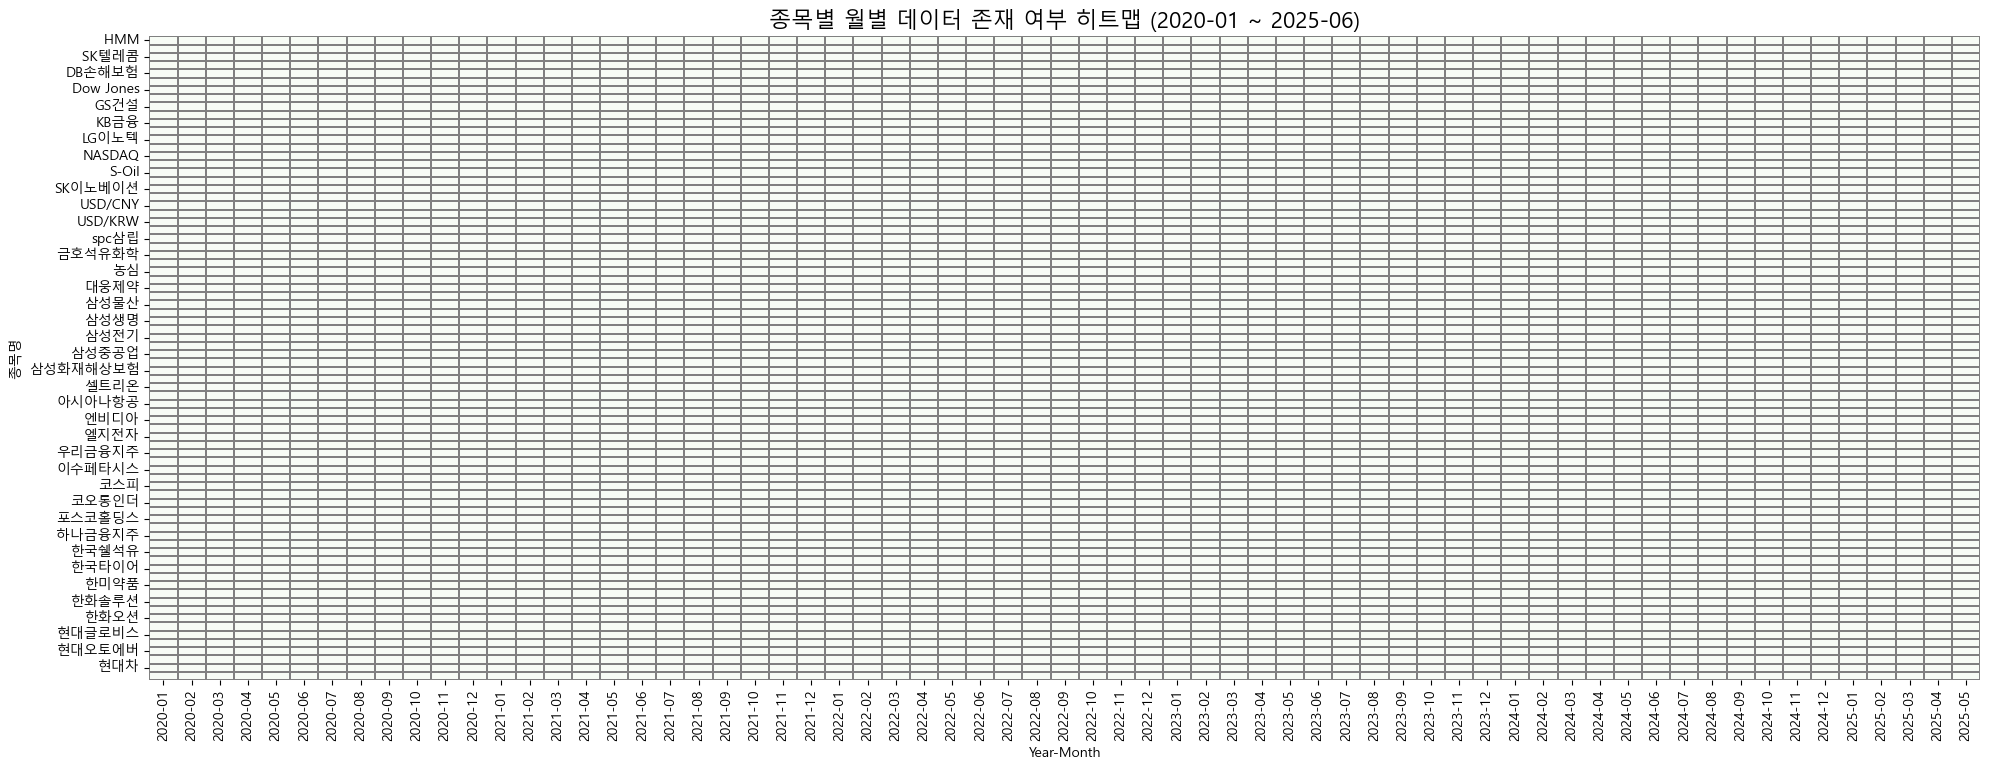

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
import warnings  # ← warnings 모듈을 임포트해야 함

# 한글 폰트 설정 (Malgun Gothic: Windows 기본 한글 폰트)
matplotlib.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 경고 무시 설정
warnings.filterwarnings('ignore')

df = pd.read_csv('stock_data_v3.csv')

# 1. 날짜 변환 및 연월 추가
df['date'] = pd.to_datetime(df['date'])
df['year_datemonth'] = df['date'].dt.to_period('D').astype(str)

# 2. 피벗 테이블 생성 (존재 여부만 확인용 → count or 1)
df_heatmap = (
    df.groupby(['keyword', 'year_month'])['date']
    .count()
    .unstack(fill_value=0)
)

# 3. 0은 없음, 1 이상은 있음으로 처리
df_heatmap_binary = (df_heatmap > 0).astype(int)

# 4. 시각화
plt.figure(figsize=(20, len(df_heatmap_binary) * 0.1))
sns.heatmap(df_heatmap_binary, cmap='Greens', cbar=False, linewidths=0.2, linecolor='gray')
plt.title('종목별 월별 데이터 존재 여부 히트맵 (2020-01 ~ 2025-06)', fontsize=16)
plt.xlabel('Year-Month')
plt.ylabel('종목명')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()